#LAB 02
# Chuẩn hóa và kiểm soát dữ liệu trong xử lý ảnh


Setup môi trường


In [1]:
import numpy as np
import matplotlib.pyplot as plt


Bài 1: Khởi tạo ảnh bằng Numpy Array


[[  0  30  60  90 120 150 180 210]
 [ 10  40  70 100 130 160 190 220]
 [ 20  50  80 110 140 170 200 230]
 [ 30  60  90 120 150 180 210 240]
 [ 40  70 100 130 160 190 220 250]
 [ 50  80 110 140 170 200 230 255]]
Shape:  (6, 8)
dtype:  uint8
min/max:  0 255
mean:  129.89583333333334
Std:  70.64059255111201


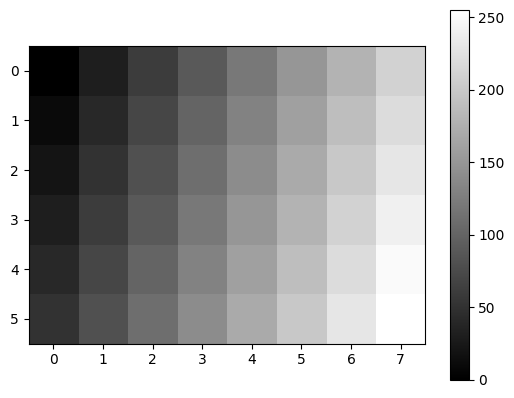

In [39]:
img = np.array([
    [0, 30, 60, 90, 120, 150, 180, 210],
    [10, 40, 70, 100, 130, 160, 190, 220],
    [20, 50, 80, 110, 140, 170, 200, 230],
    [30, 60, 90, 120, 150, 180, 210, 240],
    [40, 70, 100, 130, 160, 190, 220, 250],
    [50, 80, 110, 140, 170, 200, 230, 255]
], dtype = np.uint8)

print(img)
print("Shape: ", img.shape)
print("dtype: ", img.dtype)
print("min/max: ", img.min(), img.max())
print("mean: ", img.mean())
print("Std: ", img.std())

plt.imshow(img, cmap = "gray", vmin = 0, vmax = 255 )
plt.colorbar()
plt.show()

shape: (6, 8)
Cho biết kích thước ảnh: 6 hàng × 8 cột, tức ảnh cao 6 pixel, rộng 8 pixel. Đây là ảnh xám (grayscale) nên chỉ có 2 chiều (không có chiều kênh màu như ảnh RGB có shape (6,8,3)).

dtype: uint8
Kiểu dữ liệu là số nguyên không dấu 8-bit, có giá trị từ 0 đến 255. Đây là kiểu dữ liệu tiêu chuẩn để lưu trữ cường độ pixel ảnh xám, vì 8 bit đủ để biểu diễn 256 mức xám (từ đen tuyệt đối = 0 đến trắng tuyệt đối = 255).

min/max: 0, 255

min = 0: pixel tối nhất trong ảnh có giá trị 0 (màu đen).
max = 255: pixel sáng nhất trong ảnh có giá trị 255 (màu trắng).
→ Ảnh sử dụng toàn bộ dải động (dynamic range) từ 0 đến 255, nghĩa là có độ tương phản (contrast) khá lớn, trải đều từ vùng tối nhất đến vùng sáng nhất có thể.

mean: 129.9
Giá trị trung bình của tất cả các pixel. Đây là chỉ số phản ánh độ sáng tổng thể của ảnh. Vì mean ≈ 130, gần với giá trị giữa (127.5) của thang 0–255, nên ảnh có độ sáng trung bình, không quá tối cũng không quá sáng.

std: 70.6
Độ lệch chuẩn (standard deviation) đo mức độ phân tán / độ tương phản của các giá trị pixel so với mean. Std càng lớn thì ảnh càng có độ tương phản cao (chênh lệch sáng-tối rõ rệt giữa các vùng); std càng nhỏ thì ảnh càng "phẳng", các pixel có giá trị gần giống nhau (độ tương phản thấp). Với std ≈ 70.6 (khá lớn so với thang 255), ảnh này có độ tương phản tương đối cao.

Nhận xét

Nhìn vào ma trận, giá trị pixel tăng dần đều theo cả hai chiều (từ trái sang phải và từ trên xuống dưới) — đây là một gradient tuyến tính, tạo hiệu ứng chuyển từ tối (góc trên-trái) sang sáng (góc dưới-phải). Việc mean nằm gần giữa thang xám và std lớn phản ánh đúng bản chất đó: ảnh trải đều từ đen đến trắng một cách có quy luật, không có vùng chi tiết phức tạp hay nhiễu ngẫu nhiên.

#Bài 2: Overflow và underflow

#Overflow

Dự đoán:
200 + 100 = 300
220 + 100 = 320
250 + 100 = 350

In [6]:
x = np.array([200, 220, 250], dtype=np.uint8)

print("Original x: ", x)
print("x + 100: ", x + np.uint8(100))



Original x:  [200 220 250]
x + 100:  [44 64 94]


Kết quả thực tế lần lượt là: 44, 64, 94

Nhận xét: Kiểu dữ liệu uint8 (unsigned 8-bit integer) chỉ có thể biểu diễn các giá trị nguyên trong khoảng 0 đến 255 (vì 8 bit = 2⁸ = 256 giá trị khả dĩ). Khi kết quả phép cộng vượt quá 255, giá trị sẽ không được "giữ lại" như số nguyên bình thường (Python int) mà sẽ bị tràn số (overflow) — nó "quấn vòng" (wrap around) theo kiểu modulo 256:

#Underflow

In [7]:
x = np.array([10, 20, 30], dtype=np.uint8)

unsafe = x - np.uint8(50)

safe = np.clip(
    x.astype(np.float32) - 50,
    0, 255
).astype(np.uint8)

print("unsafe: ", unsafe)
print("safe: ", safe)

unsafe:  [216 226 236]
safe:  [0 0 0]


Đây là hiện tượng underflow — ngược lại với overflow ở phần trước. Vì x có dtype uint8 và np.uint8(50) cũng là uint8, nên phép trừ x - np.uint8(50) được thực hiện hoàn toàn trong không gian số uint8. Khi kết quả toán học là số âm, nó sẽ bị "quấn vòng" (wrap around) theo kiểu modulo 256:


x.astype(np.float32) — Ép kiểu ảnh từ uint8 sang float32 trước khi trừ. float32 có thể biểu diễn được cả số âm và số thập phân, nên phép trừ 10 - 50 = -40 được tính đúng theo toán học, không bị wrap-around.

np.clip(..., 0, 255) — Sau khi có kết quả đúng về mặt toán học (có thể âm hoặc >255), hàm clip sẽ "kẹp"/giới hạn mọi giá trị nằm ngoài khoảng [0, 255] về lại biên gần nhất:

#Bài 3: Chuyển uint8 -> float32 và chuẩn hóa

In [9]:
from matplotlib.colors import Normalize
values = np.array([32, 64, 100, 128, 200, 255],
                  dtype=np.uint8)

Normalized = values.astype(np.float32) / 255.0

print("values: ", values)
print("Normalized: ", Normalized)
print("dtype", Normalized.dtype)

values:  [ 32  64 100 128 200 255]
Normalized:  [0.1254902  0.2509804  0.39215687 0.5019608  0.78431374 1.        ]
dtype float32


uint8	float32/255	Nhận xét
32	- 0.1255	Giá trị pixel khá tối, tương ứng mức xám thấp (~12.5% độ sáng tối đa)

64	- 0.2510	Vùng tối vừa (~25% độ sáng tối đa)

100	- 0.3922	Xám trung bình – tối (~39% độ sáng)

128	- 0.5020	Xám trung bình, gần đúng điểm giữa của thang độ sáng (50%)

200	- 0.7843	Vùng sáng (~78% độ sáng tối đa)

255	- 1.0000	Giá trị lớn nhất → chuẩn hóa về đúng 1.0, tức trắng tuyệt đối / độ sáng tối đa

- trả lời: Tránh mất dữ liệu do chia số nguyên (integer division): Nếu giữ dtype là uint8 và thực hiện phép chia, NumPy sẽ làm tròn/cắt bỏ phần thập phân, khiến hầu hết kết quả trở thành 0. Ví dụ 100/255 trong toán nguyên sẽ ra 0, mất hoàn toàn thông tin. Phải chuyển sang float32 trước để phép chia giữ được phần thập phân chính xác.

# Bài 4: Chuẩn hóa Min-Max

# Chuẩn hóa về [0, 1]

In [10]:
def minmax_normalized_01(gray):
  r = gray.astype(np.float32)

  r_min = r.min()
  r_max = r.max()

  if r_max == r_min:
    return np.zeros_like(r, dtype=np.float32)

  normalized =  (r - r_min) / (r_max - r_min)
  return normalized
norm01 = minmax_normalized_01(img)

print("dtype: ", norm01.dtype)
print("min/max: ", norm01.min(), norm01.max())
print(norm01)


dtype:  float32
min/max:  0.0 1.0
[[0.         0.11764706 0.23529412 0.3529412  0.47058824 0.5882353
  0.7058824  0.8235294 ]
 [0.03921569 0.15686275 0.27450982 0.39215687 0.50980395 0.627451
  0.74509805 0.8627451 ]
 [0.07843138 0.19607843 0.3137255  0.43137255 0.54901963 0.6666667
  0.78431374 0.9019608 ]
 [0.11764706 0.23529412 0.3529412  0.47058824 0.5882353  0.7058824
  0.8235294  0.9411765 ]
 [0.15686275 0.27450982 0.39215687 0.50980395 0.627451   0.74509805
  0.8627451  0.98039216]
 [0.19607843 0.3137255  0.43137255 0.54901963 0.6666667  0.78431374
  0.9019608  1.        ]]


#Giải thích vì sao nên giữ kết quả ở float32 thay vì chuyển ngay về uint8
- uint8 không biểu diễn được số trong khoảng [0,1]: Sau khi chuẩn hóa, gần như mọi giá trị đều là số thập phân nằm giữa 0 và 1 (ví dụ 0.1176, 0.5882...). Nếu ép ngay về uint8, toàn bộ các số này sẽ bị làm tròn xuống 0 (vì uint8 chỉ lưu số nguyên), khiến ảnh chuẩn hóa trở thành toàn số 0 — mất sạch thông tin.

- Giữ độ chính xác cho các bước xử lý tiếp theo: Dữ liệu chuẩn hóa [0,1] thường được đưa tiếp vào các phép toán khác (nhân với hệ số, cộng bias, đưa vào mô hình học máy, tính gradient, filter...). Nếu làm tròn về uint8 ngay, các phép tính sau đó sẽ mất độ chính xác nghiêm trọng và tích lũy sai số.

# Stretching về [ 0, 255 ]

In [12]:
def minmax_stretch_255(gray):
  r = gray.astype(np.float32)
  r_min = r.min()
  r_max = r.max()

  if r_max == r_min:
    return gray.copy()

  s = 255.0 * ( r - r_min ) / ( r_max - r_min )
  return s.astype(np.uint8)

stretched = minmax_stretch_255(img)

print("dtype: ", stretch.dtype)
print("min/max: ", stretch.min(), stretch.max())
print(stretched)

dtype:  uint8
min/max:  0 255
[[  0  30  60  90 120 150 180 210]
 [ 10  40  70 100 130 160 190 220]
 [ 20  50  80 110 140 170 200 230]
 [ 30  60  90 120 150 180 210 240]
 [ 40  70 100 130 160 190 220 250]
 [ 50  80 110 140 170 200 230 255]]


#Nhận xét:
Nhận xét: So sánh 3 miền giá trị
Trường hợp ảnh gốc (Bài 1) — đã trải hết dải [0,255]

Ảnh gốc	uint8	0	255	Dải cường độ ban đầu

Chuẩn hóa [0,1]	float32	0.0	1.0	Co dải [0,255] về [0,1], tỉ lệ tương đối giữ nguyên

Min-Max Stretch [0,255]	uint8	0	255	Trùng với ảnh gốc vì ảnh gốc đã dùng hết dải động

# Ảnh có miền cường độ hẹp

Original min/max : 80 140
Stretched min/max: 0 255


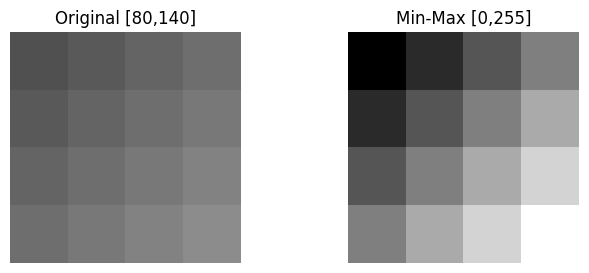

In [13]:
img_low = np.array([
    [ 80,  90, 100, 110],
    [ 90, 100, 110, 120],
    [100, 110, 120, 130],
    [110, 120, 130, 140]
], dtype=np.uint8)

stretched_low = minmax_stretch_255(img_low)

print("Original min/max :", img_low.min(), img_low.max())
print("Stretched min/max:", stretched_low.min(), stretched_low.max())

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.imshow(img_low, cmap="gray", vmin=0, vmax=255)
plt.title("Original [80,140]")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(stretched_low, cmap="gray", vmin=0, vmax=255)
plt.title("Min-Max [0,255]")
plt.axis("off")
plt.show()

1. Vì sao Min-Max Stretching làm tăng độ tương phản?

- Ảnh img_low gốc chỉ có giá trị nằm trong khoảng hẹp [80, 140] — tức chỉ chiếm khoảng (140−80)/255 ≈ 23.5% toàn bộ dải động 0–255 mà uint8 có thể biểu diễn. Vì khoảng chênh lệch giữa các pixel quá nhỏ so với thang 0–255, mắt người khó phân biệt được sự khác nhau giữa vùng "tối" và vùng "sáng" trong ảnh — ảnh nhìn xám đều, phẳng, thiếu tương phản.

- Công thức stretching:
s=255× (r-rmin / rmax - rmin)

- sẽ ánh xạ tuyến tính lại toàn bộ khoảng [r_min, r_max] hẹp đó thành khoảng đầy đủ [0, 255]:

- Pixel có giá trị nhỏ nhất (r_min) → 0 (đen tuyệt đối)
- Pixel có giá trị lớn nhất (r_max) → 255 (trắng tuyệt đối)
- Các giá trị trung gian được "giãn" ra tương ứng theo tỷ lệ

2. Điều gì xảy ra nếu r_min = r_max?

- Đây là trường hợp ảnh hoàn toàn đồng nhất (mọi pixel có cùng một giá trị, ví dụ toàn bộ đều bằng 120 — ảnh phẳng tuyệt đối, không có chi tiết). Khi đó mẫu số (r_max - r_min) = 0, dẫn đến phép chia cho 0:

- Nếu không kiểm tra trước, chương trình sẽ:

- Trong NumPy: cho ra NaN (0/0) hoặc cảnh báo RuntimeWarning: invalid value encountered in divide, làm hỏng toàn bộ dữ liệu ảnh.
Khi ép về uint8, giá trị NaN sẽ chuyển thành một số ngẫu nhiên/không xác định, gây lỗi khó phát hiện.

3. Vì sao cần kiểm tra trường hợp này trong hàm?

- Tránh lỗi runtime (chia cho 0) làm chương trình đưa ra kết quả sai (NaN/Inf) mà không báo lỗi rõ ràng, rất khó debug.

- Về mặt ý nghĩa: một ảnh đồng nhất (không có chênh lệch cường độ) thì không có gì để "giãn ra" — không tồn tại khái niệm tương phản trên một vùng phẳng tuyệt đối. Do đó trả về nguyên ảnh gốc (hoặc toàn số 0 với normalize [0,1]) là hành vi hợp lý và an toàn nhất.

- Đây là ví dụ điển hình của lập trình phòng thủ (defensive programming) — luôn kiểm tra các trường hợp biên (edge case) trước khi thực hiện phép toán có khả năng gây lỗi (chia cho 0, log(0), sqrt(số âm)...).

# Bài tập

In [17]:
import numpy as np

def minmax_normalize_01(gray):
    r = gray.astype(np.float32)
    r_min = r.min()
    r_max = r.max()
    if r_max == r_min:
        return np.zeros_like(r, dtype=np.float32)
    return (r - r_min) / (r_max - r_min)

def minmax_stretch_255(gray):
    r = gray.astype(np.float32)
    r_min = r.min()
    r_max = r.max()
    if r_max == r_min:
        return gray.copy()
    s = 255.0 * (r - r_min) / (r_max - r_min)
    s = np.clip(s, 0, 255)
    return s.astype(np.uint8)

# Ma trận uint8 4x4, giá trị chỉ nằm trong [100,160]
img = np.array([
    [100, 110, 120, 130],
    [110, 120, 130, 140],
    [120, 130, 140, 150],
    [130, 140, 150, 160]
], dtype=np.uint8)

norm01 = minmax_normalize_01(img)
stretched = minmax_stretch_255(img)

print("TRƯỚC XỬ LÝ (ảnh gốc)")
print(img)
print("dtype:", img.dtype)
print("min  :", img.min())
print("max  :", img.max())
print("mean :", img.mean())
print("std  :", img.std())

print()
print("SAU CHUẨN HÓA VỀ [0,1]")
print(norm01)
print("dtype:", norm01.dtype)
print("min  :", norm01.min())
print("max  :", norm01.max())
print("mean :", norm01.mean())
print("std  :", norm01.std())

print()
print("SAU MIN-MAX STRETCH VỀ [0,255]")
print(stretched)
print("dtype:", stretched.dtype)
print("min  :", stretched.min())
print("max  :", stretched.max())
print("mean :", stretched.mean())
print("std  :", stretched.std())

TRƯỚC XỬ LÝ (ảnh gốc)
[[100 110 120 130]
 [110 120 130 140]
 [120 130 140 150]
 [130 140 150 160]]
dtype: uint8
min  : 100
max  : 160
mean : 130.0
std  : 15.811388300841896

SAU CHUẨN HÓA VỀ [0,1]
[[0.         0.16666667 0.33333334 0.5       ]
 [0.16666667 0.33333334 0.5        0.6666667 ]
 [0.33333334 0.5        0.6666667  0.8333333 ]
 [0.5        0.6666667  0.8333333  1.        ]]
dtype: float32
min  : 0.0
max  : 1.0
mean : 0.5
std  : 0.26352313

SAU MIN-MAX STRETCH VỀ [0,255]
[[  0  42  85 127]
 [ 42  85 127 170]
 [ 85 127 170 212]
 [127 170 212 255]]
dtype: uint8
min  : 0
max  : 255
mean : 127.25
std  : 67.1988653178013


#Nhận xét:
- std tăng từ 15.81 (ảnh gốc, dải hẹp) lên 67.20 (sau stretch) — tăng khoảng 4.25 lần, đúng bằng hệ số giãn 255/(160−100) = 4.25, chứng minh Min-Max Stretching đã kéo giãn tuyến tính toàn bộ dữ liệu và làm tăng độ tương phản một cách định lượng rõ ràng.

#Bài 5: Cast unit8 về quá sớm

In [18]:
x = np.array([0.1, 0.25, 0.5, 0.75, 1.0],
             dtype=np.float32)

bad = x.astype(np.uint8)

print("float32: ", x)
print("uint8: ", bad)

float32:  [0.1  0.25 0.5  0.75 1.  ]
uint8:  [0 0 0 0 1]


#Nhận xét:
- uint8 là kiểu số nguyên, chỉ chứa được số nguyên từ 0 đến 255, không chứa được số thập phân (như 0.5, 0.75...).

- Khi  lấy một số thập phân (float) rồi ép nó thành uint8, máy tính sẽ cắt bỏ hết phần thập phân, chỉ giữ lại phần nguyên đứng trước dấu chấm.

# Bài 6: Brightness transform


In [40]:
def brightness_transform(gray, beta):
  r = gray.astype(np.float32)
  s = r + beta
  s = np.clip(s, 0, 255)
  return s.astype(np.uint8)


[[  0   0   0  10  40  70 100 130]
 [  0   0   0  20  50  80 110 140]
 [  0   0   0  30  60  90 120 150]
 [  0   0  10  40  70 100 130 160]
 [  0   0  20  50  80 110 140 170]
 [  0   0  30  60  90 120 150 175]]


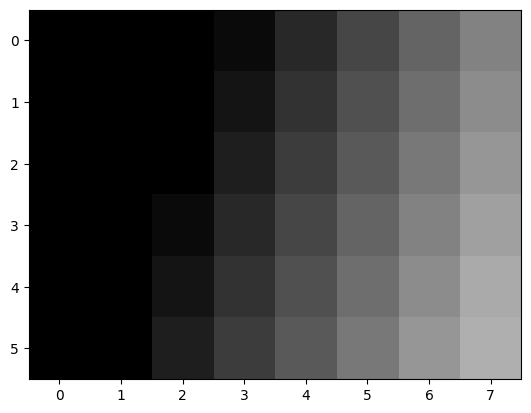

In [41]:
#beta = -80
bright = brightness_transform(img, -80)

print(bright)
plt.imshow(bright, cmap = "gray", vmin = 0, vmax = 255)
plt.show()

→ 13 pixel bị clipping về 0, 0 pixel bị clip về 255. min/max: 0/175

β = -80 (làm ảnh tối hơn nhiều)

[[  0   0  30  60  90 120 150 180]
 [  0  10  40  70 100 130 160 190]
 [  0  20  50  80 110 140 170 200]
 [  0  30  60  90 120 150 180 210]
 [ 10  40  70 100 130 160 190 220]
 [ 20  50  80 110 140 170 200 225]]


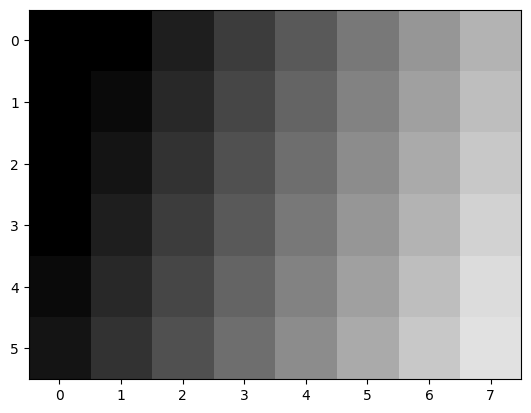

In [42]:
#beta = -30
bright = brightness_transform(img, -30)

print(bright)
plt.imshow(bright, cmap = "gray", vmin = 0, vmax = 255)
plt.show()

→ 3 pixel bị clipping về 0, 0 pixel bị clip về 255. min/max: 0/225

β = -30 (làm ảnh tối nhẹ)

[[ 30  60  90 120 150 180 210 240]
 [ 40  70 100 130 160 190 220 250]
 [ 50  80 110 140 170 200 230 255]
 [ 60  90 120 150 180 210 240 255]
 [ 70 100 130 160 190 220 250 255]
 [ 80 110 140 170 200 230 255 255]]


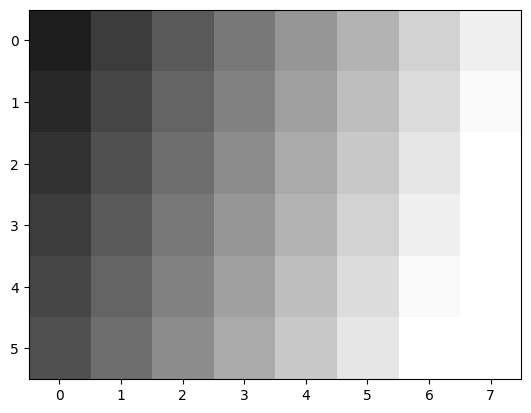

In [43]:
#beta = 30
bright = brightness_transform(img, 30)

print(bright)
plt.imshow(bright, cmap = "gray", vmin = 0, vmax = 255)
plt.show()

→ 0 pixel bị clip về 0, 5 pixel bị clipping về 255. min/max: 30/255

β = +30 (làm ảnh sáng nhẹ)

[[ 80 110 140 170 200 230 255 255]
 [ 90 120 150 180 210 240 255 255]
 [100 130 160 190 220 250 255 255]
 [110 140 170 200 230 255 255 255]
 [120 150 180 210 240 255 255 255]
 [130 160 190 220 250 255 255 255]]


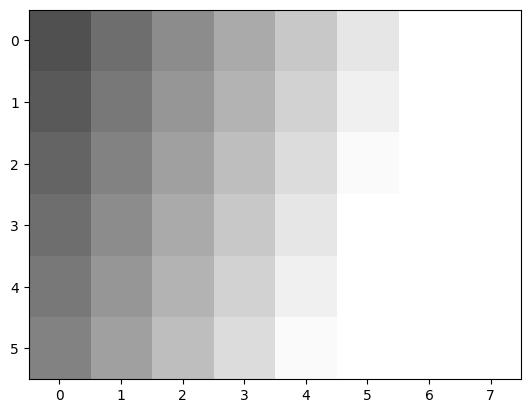

In [44]:
#beta = 80
bright = brightness_transform(img, 80)

print(bright)
plt.imshow(bright, cmap = "gray", vmin = 0, vmax = 255)
plt.show()

→ 0 pixel bị clip về 0, 15 pixel bị clipping về 255. min/max: 80/255

β = +80 (làm ảnh sáng nhiều)

# Nhận xét:

- Cơ chế clipping: Hàm dùng r = gray.astype(np.float32) trước khi cộng β, nên phép cộng được thực hiện đúng theo toán học (không bị wrap-around như uint8 ở các bài trước). Sau đó np.clip(s, 0, 255) sẽ "kẹp" các giá trị vượt ngoài khoảng hợp lệ về biên gần nhất — đây là cách xử lý an toàn so với overflow/underflow trực tiếp trên uint8.

- β âm (giảm sáng) → clipping xảy ra ở phía 0: Những pixel vốn đã tối (giá trị gốc nhỏ) khi trừ đi |β| sẽ cho kết quả âm về mặt toán học, bị kẹp về 0. β càng âm nhiều (-80 so với -30) thì càng nhiều pixel bị "dồn về 0" — thông tin chi tiết ở vùng tối bị mất hoàn toàn (nhiều pixel khác nhau đều biến thành cùng giá trị 0), tạo ra vùng đen đồng nhất, mất chi tiết (gọi là "crushed blacks").
- β dương (tăng sáng) → clipping xảy ra ở phía 255: Ngược lại, những pixel vốn đã sáng khi cộng thêm β sẽ vượt quá 255, bị kẹp về 255. β càng lớn (+80 so với +30) thì càng nhiều pixel "dồn về 255" — chi tiết vùng sáng bị mất (gọi là "blown highlights" / cháy sáng).

- Mối quan hệ tuyến tính giữa |β| và mức độ mất thông tin: So sánh -30 (3 pixel) với -80 (13 pixel), hoặc +30 (5 pixel) với +80 (15 pixel) — |β| càng lớn thì vùng giá trị bị đẩy ra ngoài biên [0,255] càng rộng, số pixel bị clip càng tăng, ảnh càng mất nhiều chi tiết ở vùng cực trị (rất tối hoặc rất sáng).

#Bài 7: Biến đổi tuyến tính

In [45]:
def linear_transform(gray, alpha = 1.0, beta = 0.0):
  r = gray.astype(np.float32)
  s = alpha * r + beta
  s = np.clip(s, 0, 255)
  return s.astype(np.uint8)

[[  0  15  30  45  60  75  90 105]
 [  5  20  35  50  65  80  95 110]
 [ 10  25  40  55  70  85 100 115]
 [ 15  30  45  60  75  90 105 120]
 [ 20  35  50  65  80  95 110 125]
 [ 25  40  55  70  85 100 115 127]]


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

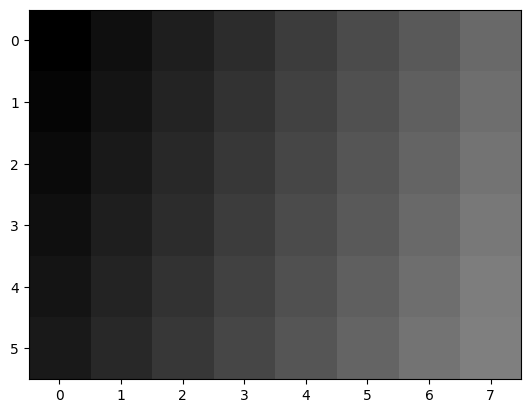

In [46]:
# Tham số (0.5, 0)
result = linear_transform(img, 0.5, 0)
print(result)
plt.imshow(result, cmap = "gray", vmin = 0, vmax = 255)
plt

[[  3  33  63  93 123 153 183 213]
 [ 13  43  73 103 133 163 193 223]
 [ 23  53  83 113 143 173 203 233]
 [ 33  63  93 123 153 183 213 243]
 [ 43  73 103 133 163 193 223 253]
 [ 53  83 113 143 173 203 233 255]]


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

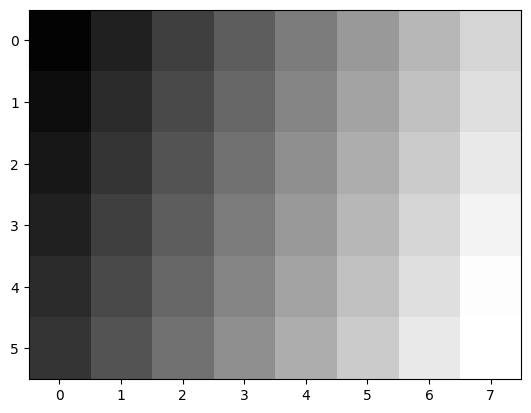

In [47]:
# Tham số (1.0, 3.0)
result = linear_transform(img, 1.0, 3.0)
print(result)
plt.imshow(result, cmap = "gray", vmin = 0, vmax = 255)
plt

[[  0  45  90 135 180 225 255 255]
 [ 15  60 105 150 195 240 255 255]
 [ 30  75 120 165 210 255 255 255]
 [ 45  90 135 180 225 255 255 255]
 [ 60 105 150 195 240 255 255 255]
 [ 75 120 165 210 255 255 255 255]]


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

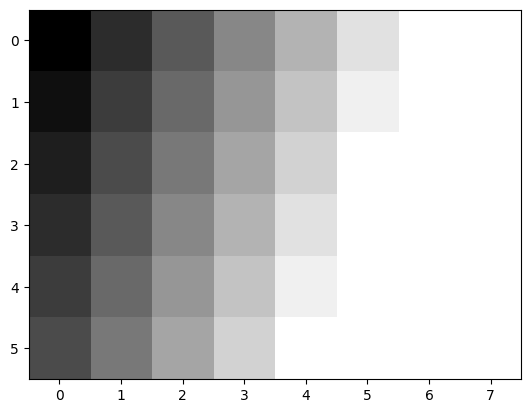

In [48]:
# Tham số (1.5, 0)
result = linear_transform(img, 1.5, 0)
print(result)
plt.imshow(result, cmap = "gray", vmin = 0, vmax = 255)
plt

[[  0  15  60 105 150 195 240 255]
 [  0  30  75 120 165 210 255 255]
 [  0  45  90 135 180 225 255 255]
 [ 15  60 105 150 195 240 255 255]
 [ 30  75 120 165 210 255 255 255]
 [ 45  90 135 180 225 255 255 255]]


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

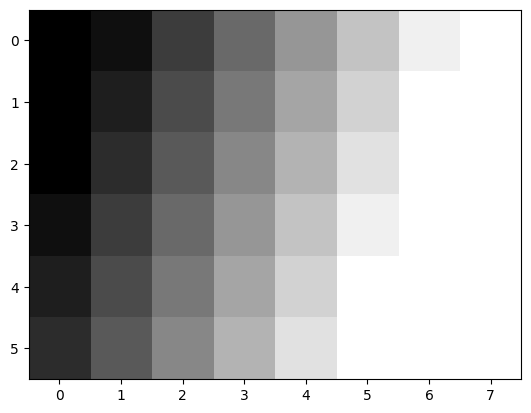

In [49]:
# Tham số (1.5, 3.0)
result = linear_transform(img, 1.5, -30)
print(result)
plt.imshow(result, cmap = "gray", vmin = 0, vmax = 255)
plt

#Nhận xét:
- α thay đổi độ tương phản (giãn/nén khoảng cách giữa các mức xám quanh 0).
- β thay đổi độ sáng tổng thể (dịch chuyển toàn bộ ảnh sáng lên/tối xuống mà không đổi độ tương phản, trừ khi gây clipping).

#Bài 8: Gamma Transform

In [50]:
def gamma_transform(gray, gamma):
    r = gray.astype(np.float32) / 255.0
    s = np.power(r, gamma)
    s = s * 255.0
    s = np.clip(s, 0, 255)
    return s.astype(np.uint8)

g05 = gamma_transform(img, 0.5)
g10 = gamma_transform(img, 1.0)
g22 = gamma_transform(img, 2.2)

[[  0  87 123 151 174 195 214 231]
 [ 50 100 133 159 182 201 220 236]
 [ 71 112 142 167 188 208 225 242]
 [ 87 123 151 174 195 214 231 247]
 [100 133 159 182 201 220 236 252]
 [112 142 167 188 208 225 242 255]]


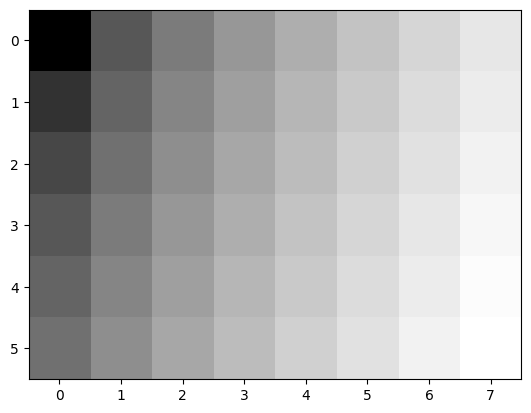

In [55]:
# gamma < 1
print(g05)
plt.imshow(g05, cmap="gray", vmin=0, vmax=255)

[[  0  30  60  90 120 150 180 210]
 [ 10  40  70 100 130 160 190 220]
 [ 20  50  80 110 140 170 200 230]
 [ 30  60  90 120 150 180 210 240]
 [ 40  70 100 130 160 190 220 250]
 [ 50  80 110 140 170 200 230 255]]


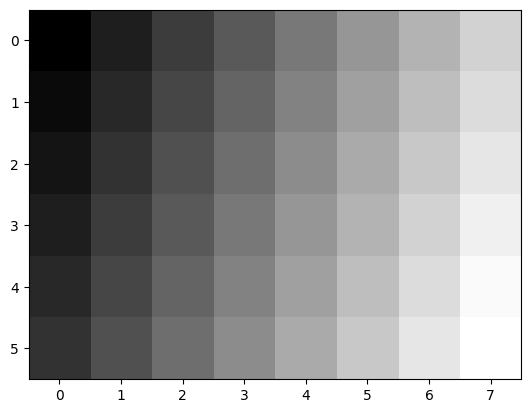

In [56]:
# gamma = 1
print(g10)
plt.imshow(g10, cmap="gray", vmin=0, vmax=255)

[[  0   2  10  25  48  79 118 166]
 [  0   4  14  32  57  91 133 184]
 [  0   7  19  40  68 104 149 203]
 [  2  10  25  48  79 118 166 223]
 [  4  14  32  57  91 133 184 244]
 [  7  19  40  68 104 149 203 255]]


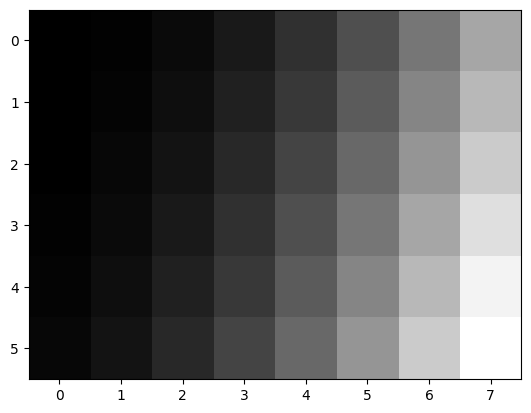

In [57]:
# gamma > 1
print(g22)
plt.imshow(g22, cmap="gray", vmin=0, vmax=255)

# Nhận xét:
- γ = 0.5: ảnh sáng lên rõ rệt so với gốc, vì lũy thừa với số mũ nhỏ hơn 1 làm các giá trị pixel (đã chuẩn hóa [0,1]) tăng lên gần 1 hơn.
- γ = 1.0: ảnh giữ nguyên như gốc, vì mọi số mũ 1 không làm thay đổi giá trị (r¹ = r).
- γ = 2.2: ảnh tối đi rõ rệt so với gốc, vì lũy thừa với số mũ lớn hơn 1 làm các giá trị pixel giảm xuống gần 0 hơn.

#Bài 9: Log Transform

[[  0 157 189 207 220 230 239 246]
 [110 170 196 212 224 233 241 248]
 [140 180 202 216 227 236 243 250]
 [157 189 207 220 230 239 246 252]
 [170 196 212 224 233 241 248 254]
 [180 202 216 227 236 243 250 255]]


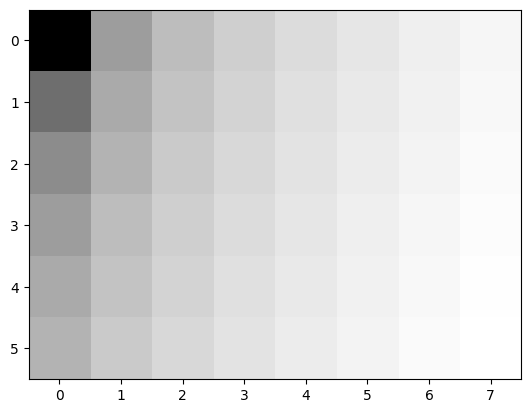

In [58]:
def log_transform(gray):
    r = gray.astype(np.float32)
    c = 255.0 / np.log(256.0)
    s = c * np.log1p(r)
    s = np.clip(s, 0, 255)
    return s.astype(np.uint8)

log_img = log_transform(img)

print(log_img)
plt.imshow(log_img, cmap="gray", vmin=0, vmax=255)
plt.show()

Trả lời: Log Transform tác động (khuếch đại) mạnh hơn lên vùng cường độ THẤP.

Giải thích dựa trên công thức: s = c·log(1+r)

Hàm logarit có đặc điểm quan trọng: độ dốc (đạo hàm) giảm dần khi r tăng lên. Cụ thể:
ds/dr = 1 / (1+r)
Vì c là hằng số dương, đạo hàm ds/dr tỉ lệ nghịch với (1+r) — nghĩa là:

Khi r nhỏ (vùng tối, gần 0): mẫu số (1+r) nhỏ → đạo hàm ds/dr rất lớn → một thay đổi nhỏ ở r gây ra thay đổi rất lớn ở s.

Khi r lớn (vùng sáng, gần 255): mẫu số (1+r) lớn → đạo hàm ds/dr rất nhỏ → cùng một thay đổi ở r chỉ gây ra thay đổi rất nhỏ ở s.

#Bài 10: Vai trò của clip


In [59]:
x = np.array([-100, -10, 0, 50, 200, 255, 300, 500],
             dtype=np.float32)

print("Before:", x)
print("After :", np.clip(x, 0, 255))

Before: [-100.  -10.    0.   50.  200.  255.  300.  500.]
After : [  0.   0.   0.  50. 200. 255. 255. 255.]


Nhận xét:
- Hàm np.clip(x, 0, 255) áp dụng quy tắc: nếu giá trị nằm ngoài khoảng [0, 255] thì "kẹp" nó về biên gần nhất; nếu đã nằm trong khoảng thì giữ nguyên.

- x < 0	ánh xạ về 0
- 0 < x < 255 giữ nguyên giá trị
- x > 255 ánh xạ về 255

#Bài 11: So sánh pipeline đúng sai

In [60]:
# Pipeline không an toàn
unsafe = img + np.uint8(100)

# Pipeline an toàn
safe = np.clip(
    img.astype(np.float32) + 100,
    0, 255
).astype(np.uint8)

print("Unsafe:")
print(unsafe)
print("\nSafe:")
print(safe)

Unsafe:
[[100 130 160 190 220 250  24  54]
 [110 140 170 200 230   4  34  64]
 [120 150 180 210 240  14  44  74]
 [130 160 190 220 250  24  54  84]
 [140 170 200 230   4  34  64  94]
 [150 180 210 240  14  44  74  99]]

Safe:
[[100 130 160 190 220 250 255 255]
 [110 140 170 200 230 255 255 255]
 [120 150 180 210 240 255 255 255]
 [130 160 190 220 250 255 255 255]
 [140 170 200 230 255 255 255 255]
 [150 180 210 240 255 255 255 255]]


Vị trí:
(0,6)
(0,7)
(1,5)
(1,6)
(1,7)
(2,5)
(2,6)
(2,7)
(3,5)
(3,6)
(3,7)
(4,4)
(4,5)
(4,6)
(4,7)
(5,4)
(5,5)
(5,6)
(5,7)

Nguyên nhân: kiểu dữ liệu khác nhau khi thực hiện phép cộng.

- Pipeline không an toàn (img + np.uint8(100)): cả img và 100 đều là kiểu uint8, nên NumPy thực hiện phép cộng hoàn toàn trong không gian số uint8 — kiểu này chỉ biểu diễn được số nguyên từ 0 đến 255. Khi kết quả toán học vượt quá 255 (ví dụ 180 + 100 = 280), giá trị sẽ bị tràn số (overflow) và "quấn vòng" (wrap around) theo công thức modulo 256:

# Bài tập TH

In [61]:
def point_transform(gray, alpha, beta):
    # TODO 1: chuyển uint8 -> float32
    r = gray.astype(np.float32)

    # TODO 2: transform s = alpha*r + beta
    s = alpha * r + beta

    # TODO 3: clip về [0,255]
    s = np.clip(s, 0, 255)

    # TODO 4: chuyển về uint8
    result = s.astype(np.uint8)

    return result

In [62]:
params = [(1.0, 0), (0.7, 0), (1.0, 50), (1.3, -40)]

for alpha, beta in params:
    out = point_transform(img, alpha, beta)
    print(f"alpha={alpha}, beta={beta}")
    print(out)
    print("dtype:", out.dtype, "min:", out.min(), "max:", out.max(),
          "mean:", out.mean(), "std:", out.std())

alpha=1.0, beta=0
[[  0  30  60  90 120 150 180 210]
 [ 10  40  70 100 130 160 190 220]
 [ 20  50  80 110 140 170 200 230]
 [ 30  60  90 120 150 180 210 240]
 [ 40  70 100 130 160 190 220 250]
 [ 50  80 110 140 170 200 230 255]]
dtype: uint8 min: 0 max: 255 mean: 129.89583333333334 std: 70.64059255111201
alpha=0.7, beta=0
[[  0  21  42  63  84 105 126 147]
 [  7  28  49  70  91 112 133 154]
 [ 14  35  56  77  98 119 140 161]
 [ 21  42  63  84 105 126 147 168]
 [ 28  49  70  91 112 133 154 175]
 [ 35  56  77  98 119 140 161 178]]
dtype: uint8 min: 0 max: 178 mean: 90.91666666666667 std: 49.430015060577205
alpha=1.0, beta=50
[[ 50  80 110 140 170 200 230 255]
 [ 60  90 120 150 180 210 240 255]
 [ 70 100 130 160 190 220 250 255]
 [ 80 110 140 170 200 230 255 255]
 [ 90 120 150 180 210 240 255 255]
 [100 130 160 190 220 250 255 255]]
dtype: uint8 min: 50 max: 255 mean: 175.3125 std: 64.22134777795205
alpha=1.3, beta=-40
[[  0   0  38  76 116 155 193 233]
 [  0  12  51  90 129 168 206 246]


#Nhận xét
(1.0, 0): trùng ảnh gốc (phép biến đổi đồng nhất).
(0.7, 0): std giảm (49.43 so với 70.64) → giảm tương phản, ảnh trông "phẳng" hơn.
(1.0, 50): mean tăng mạnh (175.31), std giảm nhẹ do bị clip ở 255 → ảnh sáng hơn đồng đều.
(1.3, -40): std tăng cao nhất (85.96) → tương phản mạnh nhất, đồng thời có clip cả hai đầu (0 và 255) do α lớn kết hợp β âm.

#Bài nâng cao

In [63]:
def clipping_risk(float_image):
    total = float_image.size

    # TODO: tính % pixel < 0
    below = np.sum(float_image < 0) / total * 100

    # TODO: tính % pixel > 255
    above = np.sum(float_image > 255) / total * 100

    return below, above

In [64]:
alpha, beta = 1.8, 80
r = img.astype(np.float32)
s = alpha * r + beta

below, above = clipping_risk(s)
print(f"Tỷ lệ pixel < 0   (below): {below:.2f}%")
print(f"Tỷ lệ pixel > 255 (above): {above:.2f}%")

Tỷ lệ pixel < 0   (below): 0.00%
Tỷ lệ pixel > 255 (above): 64.58%


Giải thích kết quả:
- Vì sao below = 0%:
- Với β = +80 (số dương, làm sáng ảnh) và α = 1.8 (số dương, chỉ khuếch đại), phép biến đổi s = 1.8r + 80 luôn cho kết quả dương với mọi r ≥ 0 (giá trị nhỏ nhất của r là 0 → s = 0×1.8+80 = 80 > 0). Do đó không có pixel nào bị âm, tỷ lệ below = 0%.

- Vì sao above = 64.58% (rất cao):

- Hệ số α = 1.8 khuếch đại mạnh giá trị pixel (gấp 1.8 lần), cộng thêm β = 80 dịch toàn bộ dải giá trị lên cao.
Ngưỡng để pixel KHÔNG bị vượt 255 là: 1.8r + 80 ≤ 255 ⟺ r ≤ 97.2
- Trong ảnh gốc, chỉ những pixel có giá trị ≤ 97 mới an toàn (không bị clip). Tra lại ảnh gốc: các giá trị {0, 10, 20, 30, 40, 50, 60, 70, 80, 90} thỏa điều kiện này — chỉ có 17/48 pixel nằm dưới ngưỡng.
- Ngược lại, 31/48 pixel (≈64.58%) có giá trị gốc > 97 sẽ cho ra s > 255 sau biến đổi, và bị "cắt" (clip) về đúng 255 khi thực hiện np.clip().

# câu hỏi báo cáo

0. Phân biệt Min-Max về [0,1] và Min-Max Stretching về [0,255]. Khi nào nên giữ kết quả ở float32?
Cả hai dùng cùng công thức nền (r-r_min)/(r_max-r_min), chỉ khác hệ số nhân cuối: về [0,1] thì không nhân gì thêm (dùng cho mô hình học máy), về [0,255] thì nhân với 255 (dùng để hiển thị/lưu ảnh). Nên giữ float32 khi dữ liệu còn cần tính toán tiếp (đưa vào mô hình, xử lý thêm) — chỉ ép về uint8 khi cần hiển thị hoặc lưu file cuối cùng.

1. Vì sao không nên thực hiện các phép biến đổi cường độ phức tạp trực tiếp trên uint8?
Vì uint8 chỉ biểu diễn số nguyên 0–255, dễ gây tràn số (overflow/underflow) khi cộng/trừ/nhân vượt ngưỡng, dẫn đến kết quả sai lệch hoàn toàn (wrap-around) mà không có cảnh báo lỗi.

2. float32 giải quyết những vấn đề nào trong quá trình tính toán?
Giải quyết được: tràn số (biểu diễn được số âm và số lớn hơn 255), mất độ chính xác thập phân (giữ được phần lẻ khi chia/chuẩn hóa), và cho phép tính toán trung gian chính xác trước khi ép về kiểu lưu trữ cuối cùng.

3. Tại sao clip phải được thực hiện trước khi cast về uint8?
Vì astype về uint8 chỉ cắt bỏ (truncate) chứ không kiểm tra giới hạn — nếu không clip trước, giá trị âm hoặc >255 sẽ bị wrap-around (modulo 256) cho ra kết quả sai hoàn toàn thay vì bão hòa đúng về 0 hoặc 255.

4. Chuẩn hóa [0,255] → [0,1] có ý nghĩa gì đối với Gamma Transform?
Phép lũy thừa (r^gamma) chỉ có ý nghĩa đúng và ổn định khi r nằm trong [0,1] (vì lũy thừa của số >1 sẽ tăng vọt không kiểm soát); chuẩn hóa về [0,1] trước giúp công thức s = 255×(r/255)^γ hoạt động đúng và dễ kiểm soát phạm vi kết quả.

5. Phân biệt ảnh hưởng của α và β trong s = αr + β.
α (nhân) điều khiển độ tương phản — giãn/nén khoảng cách giữa các mức xám quanh 0. β (cộng) điều khiển độ sáng — dịch chuyển đều toàn bộ ảnh sáng lên/tối xuống mà không đổi tương phản.

6. Gamma < 1 và gamma > 1 tác động thế nào lên ảnh?
Gamma < 1: ảnh sáng lên, khuếch đại chi tiết vùng tối, giảm tương phản. Gamma > 1: ảnh tối đi, nén vùng tối lại, làm nổi bật chi tiết vùng sáng.

7. Log transform phù hợp khi muốn mở rộng vùng cường độ nào?
Phù hợp khi muốn mở rộng (làm nổi bật chi tiết) ở vùng cường độ thấp (vùng tối) của ảnh, vì log khuếch đại mạnh giá trị nhỏ và nén giá trị lớn.

8. Nếu bỏ bước clip, ảnh đầu ra có thể sai như thế nào?
Khi ép trực tiếp từ float (có giá trị âm hoặc >255) về uint8 mà không clip, giá trị sẽ bị wrap-around sai lệch: số âm biến thành số dương lớn gần 255, số >255 biến thành số nhỏ gần 0 — làm đảo ngược hoàn toàn ý nghĩa sáng/tối của pixel, gây nhiễu nghiêm trọng trên ảnh.